In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)

In [4]:
df = pd.read_csv('../creditcard.csv')

x = df.drop('Class', axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Data loaded and preprocessed successfully!")
print("Training set size:", x_train.shape)
print("Test set size:", x_test.shape)

Data loaded and preprocessed successfully!
Training set size: (227845, 30)
Test set size: (56962, 30)


In [6]:
model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    random_state = 42,
    n_jobs = -1,
    class_weight = 'balanced'
)

print('---/Training started/---')
model.fit(x_train, y_train)
print('Training completed!')

---/Training started/---
Training completed!


In [8]:
y_pred = model.predict(x_test)
y_pred_probab = model.predict_proba(x_test)[:, 1]

print("Predictions done!")
print("Total predictions made:", len(y_pred))

Predictions done!
Total predictions made: 56962


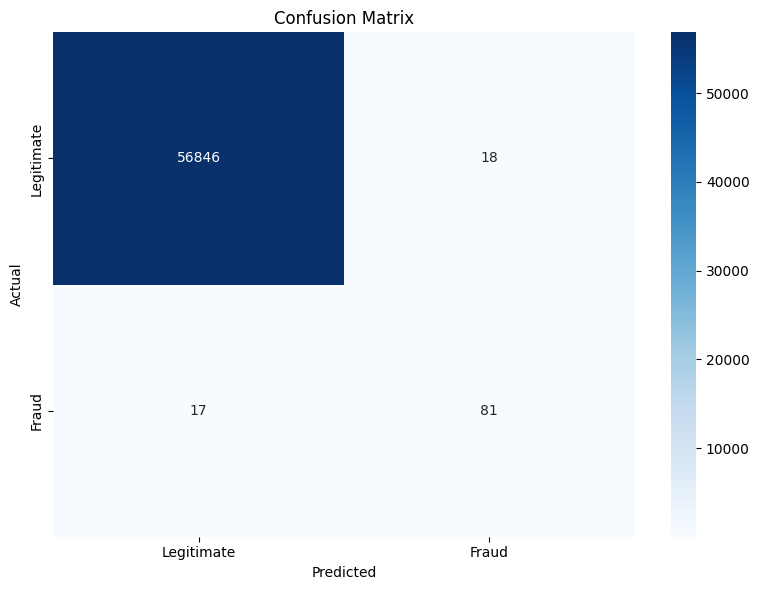


Confusion Matrix Numbers:
True Legitimate (correctly caught): 56846
False Fraud (legitimate wrongly flagged): 18
Missed Frauds (actual fraud missed): 17
True Fraud (correctly caught): 81


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels = ['Legitimate', 'Fraud'],
           yticklabels = ['Legitimate', 'Fraud'])

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png')
plt.show()

print("\nConfusion Matrix Numbers:")
print(f"True Legitimate (correctly caught): {cm[0][0]}")
print(f"False Fraud (legitimate wrongly flagged): {cm[0][1]}")
print(f"Missed Frauds (actual fraud missed): {cm[1][0]}")
print(f"True Fraud (correctly caught): {cm[1][1]}")

In [14]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

roc_auc = roc_auc_score(y_test, y_pred_probab)
print(f"ROC-AUC Score: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9766


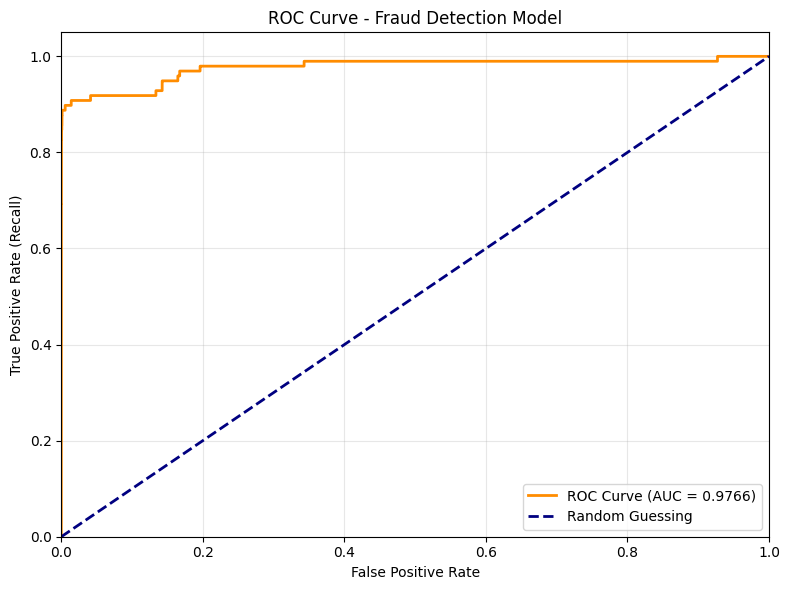

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probab)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Fraud Detection Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curve.png')
plt.show()

Top 10 Most Important Features:
1. V14: 0.1858
2. V10: 0.1150
3. V12: 0.1040
4. V17: 0.0964
5. V4: 0.0932
6. V3: 0.0723
7. V11: 0.0538
8. V16: 0.0379
9. V2: 0.0362
10. V9: 0.0260


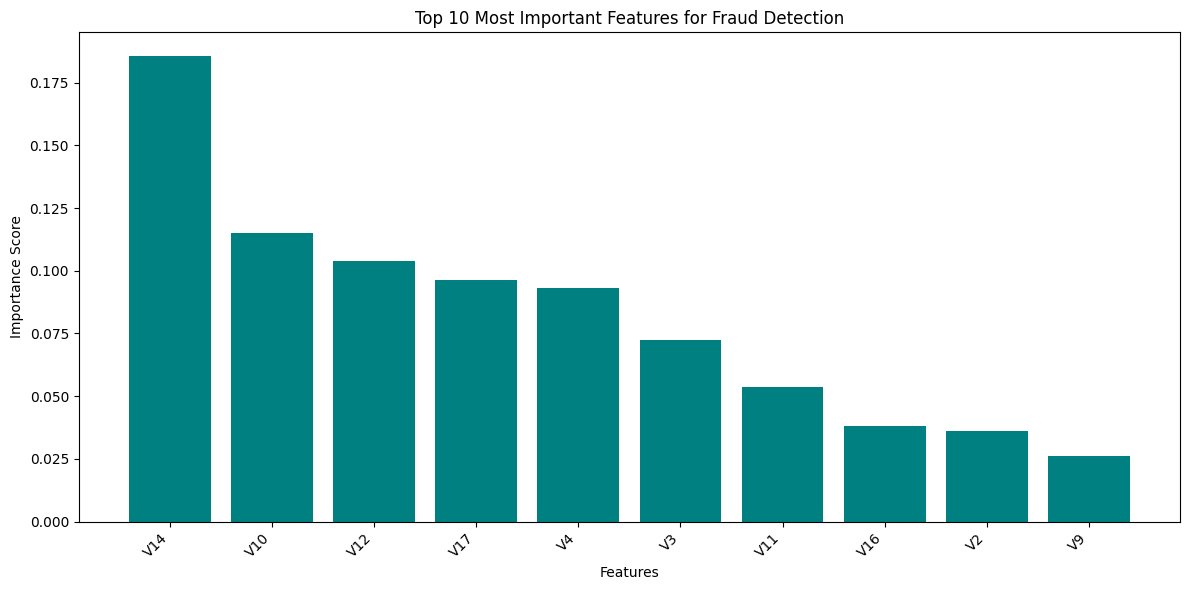

In [17]:
feature_names = df.drop('Class', axis=1).columns
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 10 Most Important Features:")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

plt.figure(figsize=(12, 6))
plt.bar(range(10), 
        importances[indices[:10]], 
        color='teal')
plt.xticks(range(10), 
           [feature_names[indices[i]] for i in range(10)], 
           rotation=45, 
           ha='right')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Top 10 Most Important Features for Fraud Detection')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()

In [22]:
import joblib

joblib.dump(model, '../model/fraud_detection_model.pkl')
joblib.dump(scaler, '../model/scaler.pkl')

print("Model saved successfully!")

Model saved successfully!


In [24]:
loaded_model = joblib.load('../model/fraud_detection_model.pkl')
loaded_scaler = joblib.load('../model/scaler.pkl')

test_sample = x_test[:5]
predictions = loaded_model.predict(test_sample)

print("Model loaded successfully!")
print("Test predictions:", predictions)
print("0 = Legitimate, 1 = Fraud")

Model loaded successfully!
Test predictions: [0 0 0 0 0]
0 = Legitimate, 1 = Fraud
